OilyGiant is a mining company planning to develop a new oil well, and the key business challenge is to determine which of three regions offers the highest potential profit while keeping financial risk at an acceptable level. Each region contains geological data from previously explored oil wells, including several features and the known volume of reserves. Using this historical data, we aim to build a predictive model that estimates the volume of reserves in new wells and supports an informed investment decision.

In this project, a linear regression model is trained and evaluated separately for each region to predict oil reserve volumes. Based on these predictions, the most promising wells are selected, and potential profit is calculated under fixed business constraints such as development budget, revenue per barrel, and the number of wells to be developed. To account for uncertainty and risk, the bootstrapping technique is applied to simulate profit distributions and estimate confidence intervals and the probability of losses.

The final objective is to identify the region that meets the required risk threshold (loss probability below 2.5%) and delivers the highest expected profit, thereby providing a data-driven recommendation for oil well development.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [2]:
Region_A = pd.read_csv('geo_data_0.csv')
Region_B = pd.read_csv('geo_data_1.csv')
Region_C = pd.read_csv('geo_data_2.csv')


In [3]:






print(Region_A.describe())
print(Region_B.describe())
print(Region_C.describe())




                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985       1.000021      26.953261
50%       

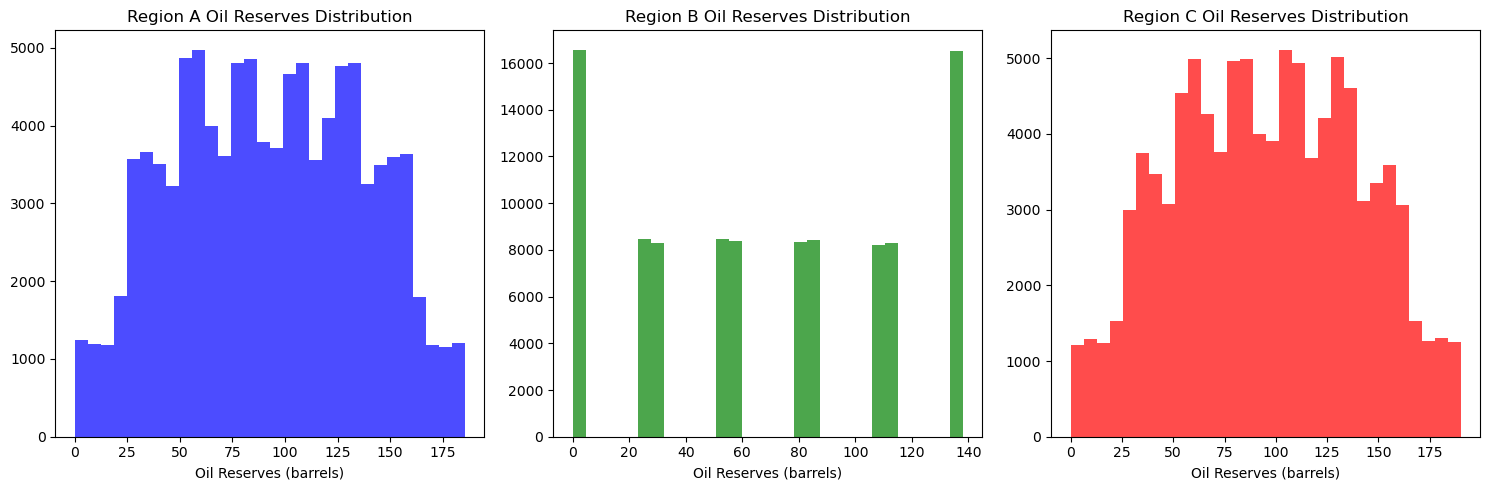

In [4]:


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(Region_A['product'], bins=30, alpha=0.7, color='blue')
axes[0].set_title('Region A Oil Reserves Distribution')
axes[0].set_xlabel('Oil Reserves (barrels)')

axes[1].hist(Region_B['product'], bins=30, alpha=0.7, color='green')
axes[1].set_title('Region B Oil Reserves Distribution')
axes[1].set_xlabel('Oil Reserves (barrels)')

axes[2].hist(Region_C['product'], bins=30, alpha=0.7, color='red')
axes[2].set_title('Region C Oil Reserves Distribution')
axes[2].set_xlabel('Oil Reserves (barrels)')

plt.tight_layout()
plt.show()

In [5]:
print(Region_A.isnull().sum())
print(Region_B.isnull().sum())
print(Region_C.isnull().sum())

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


In [6]:
print(Region_A.duplicated().sum())
print(Region_B.duplicated().sum())
print(Region_C.duplicated().sum())



0
0
0


In [7]:


print(Region_A['id'].duplicated().sum())
print(Region_B['id'].duplicated().sum())
print(Region_C['id'].duplicated().sum())



10
4
4


In [8]:
Region_A = Region_A.drop_duplicates(subset=['id'], keep='first')
Region_B = Region_B.drop_duplicates(subset=['id'], keep='first')
Region_C = Region_C.drop_duplicates(subset=['id'], keep='first')

In [9]:
print(Region_A.describe())
print(Region_B.describe())
print(Region_C.describe())


                 f0            f1            f2       product
count  99990.000000  99990.000000  99990.000000  99990.000000
mean       0.500454      0.250141      2.502629     92.499684
std        0.871844      0.504430      3.248149     44.288304
min       -1.408605     -0.848218    -12.088328      0.000000
25%       -0.072572     -0.200877      0.287784     56.497069
50%        0.502405      0.250252      2.515969     91.847928
75%        1.073626      0.700640      4.715035    128.563699
max        2.362331      1.343769     16.003790    185.364347
                 f0            f1            f2       product
count  99996.000000  99996.000000  99996.000000  99996.000000
mean       1.141209     -4.796608      2.494501     68.823916
std        8.965815      5.119906      1.703579     45.944663
min      -31.609576    -26.358598     -0.018144      0.000000
25%       -6.298551     -8.267985      1.000021     26.953261
50%        1.153055     -4.813172      2.011475     57.085625
75%     

In [10]:
print(Region_A.columns)
print(Region_A.dtypes)
print(Region_B.columns)
print(Region_B.dtypes)
print(Region_C.columns)
print(Region_C.dtypes)
Region_A = Region_A.drop('id', axis=1)
Region_B = Region_B.drop('id', axis=1)
Region_C = Region_C.drop('id', axis=1)


Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


Before training the model, the data was explored by checking column names, data types, and duplicated observations.

Duplicate well IDs were removed to ensure that each oil well is represented only once. Keeping duplicates could lead to data leakage between training and validation sets

The id column was removed because it is a non-numeric unique identifier with no predictive value. Linear regression requires numeric features, and including id would prevent the model from training and violate the model’s assumptions.

In [11]:


Region_A_train, Region_A_valid = train_test_split(Region_A, test_size=0.25, random_state=12345)

Region_A_train_target = Region_A_train['product']
Region_A_train_features = Region_A_train.drop('product', axis=1)
print('Region A train shape:')
print(Region_A_train.shape)
print(Region_A_train_target.shape)
print(Region_A_train_features.shape)
print('Region A valid shape')
Region_A_valid_target = Region_A_valid['product']
Region_A_valid_features = Region_A_valid.drop('product', axis=1)
print(Region_A_valid.shape)
print(Region_A_valid_target.shape)
print(Region_A_valid_features.shape)




Region A train shape:
(74992, 4)
(74992,)
(74992, 3)
Region A valid shape
(24998, 4)
(24998,)
(24998, 3)


In [12]:
Region_B_train, Region_B_valid = train_test_split(Region_B, test_size=0.25, random_state=12345)
Region_B_target = Region_B['product']
Region_B_features = Region_B.drop('product', axis=1)

In [13]:
Region_C_train, Region_C_valid = train_test_split(Region_C, test_size=0.25, random_state=12345)
Region_C_target = Region_C['product']
Region_C_features = Region_C.drop('product', axis=1)

In [14]:
Region_B_train, Region_B_valid = train_test_split(
    Region_B, test_size=0.25, random_state=12345
)

Region_B_train_target = Region_B_train['product']
Region_B_train_features = Region_B_train.drop('product', axis=1)

print('Region B train shape:')
print(Region_B_train.shape)
print(Region_B_train_target.shape)
print(Region_B_train_features.shape)

Region_B_valid_target = Region_B_valid['product']
Region_B_valid_features = Region_B_valid.drop('product', axis=1)

print('Region B valid shape:')
print(Region_B_valid.shape)
print(Region_B_valid_target.shape)
print(Region_B_valid_features.shape)

Region B train shape:
(74997, 4)
(74997,)
(74997, 3)
Region B valid shape:
(24999, 4)
(24999,)
(24999, 3)


In [15]:
Region_C_train, Region_C_valid = train_test_split(
    Region_C, test_size=0.25, random_state=12345
)

Region_C_train_target = Region_C_train['product']
Region_C_train_features = Region_C_train.drop('product', axis=1)

print('Region C train shape:')
print(Region_C_train.shape)
print(Region_C_train_target.shape)
print(Region_C_train_features.shape)

Region_C_valid_target = Region_C_valid['product']
Region_C_valid_features = Region_C_valid.drop('product', axis=1)

print('Region C valid shape:')
print(Region_C_valid.shape)
print(Region_C_valid_target.shape)
print(Region_C_valid_features.shape)

Region C train shape:
(74997, 4)
(74997,)
(74997, 3)
Region C valid shape:
(24999, 4)
(24999,)
(24999, 3)


In this project, linear regression is used because the task is to predict the volume of oil reserves in each well, which is a continuous numerical value measured in thousands of barrels. This makes the problem a regression task rather than a classification one.

The target variable, product, represents an exact quantity of oil that can take any numerical value within a range. Since the company needs precise reserve estimates to calculate expected profits and select the top 200 most profitable wells, predicting exact values is essential. 

In [16]:



model = LinearRegression()

model.fit(Region_A_train_features, Region_A_train_target) 
region_A_predictions_valid = model.predict(Region_A_valid_features)

region_A_result = mean_squared_error(Region_A_valid_target, region_A_predictions_valid)
region_A_result = region_A_result** 0.5
print("RMSE of the linear regression model on the validation set:", region_A_result)                                           


print("Average predicted reserves (Region A):", region_A_predictions_valid.mean())
print("Average actual reserves (Region A):", Region_A_valid_target.mean())
print("RMSE as % of mean:", (region_A_result / Region_A_valid_target.mean()) * 100)




RMSE of the linear regression model on the validation set: 37.853527328872964
Average predicted reserves (Region A): 92.78915638280621
Average actual reserves (Region A): 92.15820490940044
RMSE as % of mean: 41.07450591739095


In [17]:

model_B = LinearRegression()

model_B.fit(Region_B_train_features, Region_B_train_target)
region_B_predictions_valid = model_B.predict(Region_B_valid_features)

region_B_result = mean_squared_error(
    Region_B_valid_target, region_B_predictions_valid
) ** 0.5

print("RMSE of the linear regression model on the validation set (Region B):",
      region_B_result)
print("Average predicted reserves (Region B):", region_B_predictions_valid.mean())
print("Average actual reserves (Region B):", Region_B_valid_target.mean())
print("RMSE as % of mean:", (region_B_result / Region_B_valid_target.mean()) * 100)

RMSE of the linear regression model on the validation set (Region B): 0.8920592647717022
Average predicted reserves (Region B): 69.17831957030432
Average actual reserves (Region B): 69.18604400957675
RMSE as % of mean: 1.2893630175591817


In [18]:

model_C = LinearRegression()

model_C.fit(Region_C_train_features, Region_C_train_target)
region_C_predictions_valid = model_C.predict(Region_C_valid_features)

region_C_result = mean_squared_error(
    Region_C_valid_target, region_C_predictions_valid
) ** 0.5

print("RMSE of the linear regression model on the validation set (Region C):",
      region_C_result)
print("Average predicted reserves (Region C):", region_C_predictions_valid.mean())
print("Average actual reserves (Region C):", Region_C_valid_target.mean())
print("RMSE as % of mean:", (region_C_result / Region_C_valid_target.mean()) * 100)


RMSE of the linear regression model on the validation set (Region C): 40.07585073246016
Average predicted reserves (Region C): 94.86572480562035
Average actual reserves (Region C): 94.7851093536914
RMSE as % of mean: 42.28074536783705


Region B has an RMSE of only 0.89 thousand barrels, which represents just 1.3% error relative to the mean reserves. In contrast, Regions A and C have RMSE values of 37.85 and 40.08 thousand barrels respectively, representing over 40% error relative to their means.
Prediction accuracy is critical when selecting the top 200 wells for development, as all profitability decisions depend on the reliability of the model’s estimates. Region B clearly stands out with an RMSE of just 0.89 thousand barrels, corresponding to only 1.3% error relative to its mean reserve volume, which allows predicted values to closely match actual outcomes. In contrast, Regions A and C have RMSE values of 37.85 and 40.08 thousand barrels, representing errors of over 40% relative to their means. Even though Regions A and C show higher potential in their reserve distributions, these large prediction errors introduce massive uncertainty into well selection. A well predicted to contain 150 thousand barrels could realistically hold only 90 thousand barrels, making it nearly impossible to reliably identify the truly high-value wells in the upper tail of the distribution. As a result, Region B’s lower average reserves are outweighed by its exceptional prediction accuracy, enabling far more confident well selection, higher expected profits, and significantly lower financial risk.

To begin evaluating the potential profitability of each region, we first determine the minimum volume of oil (in thousands of barrels) required for the OilyGiant Mining Company to break even and avoid operating at a loss.

In [19]:
cost = 100_000_000  
wells_to_develop = 200  
revenue_per_barrel = 4.5

# revenue_of_well = revenue_per_barrel*1000
cost_per_well = cost / wells_to_develop  
print('cost_of_well', cost_per_well)
print('cost_of_project', cost)


cost_of_well 500000.0
cost_of_project 100000000


In [20]:

min_reserves_per_well = cost_per_well / revenue_per_barrel
min_reserves_per_project = cost / revenue_per_barrel


print(f"Minimum reserves to break even per well: {min_reserves_per_well / 1000:.0f} thousand barrels")
print(f"Minimum reserves to break even per project: {min_reserves_per_project / 1000:.0f} thousand barrels")
print(f"From 200 wells, we need: {min_reserves_per_project / 1000:.0f} thousand barrels to generate ${cost:,.0f} revenue to break even")


Minimum reserves to break even per well: 111 thousand barrels
Minimum reserves to break even per project: 22222 thousand barrels
From 200 wells, we need: 22222 thousand barrels to generate $100,000,000 revenue to break even


In [21]:
# Compare with actual averages

print(f"Region A average reserves: {Region_A['product'].mean():.1f}")
print(f"Break-even point: {min_reserves_per_well/ 1000:.1f}")
print(f"Region B average reserves: {Region_B['product'].mean():.1f}")
print(f"Break-even point: {min_reserves_per_well/ 1000:.1f}")
print(f"Region C average reserves: {Region_C['product'].mean():.1f}")
print(f"Break-even point: {min_reserves_per_well/ 1000:.1f}")


Region A average reserves: 92.5
Break-even point: 111.1
Region B average reserves: 68.8
Break-even point: 111.1
Region C average reserves: 95.0
Break-even point: 111.1


All regions fall below the break-even threshold when considering average reserves. Region A averages 92.5 thousand barrels, Region B 68.8 thousand barrels, and Region C 95.0 thousand barrels, all well below the required 111 thousand barrels per well for profitability. This confirms that profitability cannot rely on average wells and instead depends entirely on correctly identifying and developing only the top-performing wells from each region’s distribution. To evaluate how reliably this can be done, we apply bootstrapping, repeatedly sampling 200 wells from a pool of 500 and running this process 1,000 times. This approach allows us to simulate real-world decision-making under uncertainty, estimate expected profit, and quantify the risk of losses based on the model’s prediction accuracy.

In [22]:


def revenue(target, probabilities, count):
    probs_sorted = probabilities.sort_values(ascending=False)
    selected = target[probs_sorted.index][:count]
    total_reserves = selected.sum()  # Total reserves from 200 wells
    total_revenue = total_reserves * revenue_per_barrel * 1000  # Convert to barrels
    total_cost = count * cost_per_well  # Cost of developing 200 wells
    profit = total_revenue - total_cost  # Total profit in dollars
    return profit
    
region_A_predictions_valid = pd.Series(
    region_A_predictions_valid, 
    index=Region_A_valid_target.index
)
state = np.random.RandomState(12345)
    
values = []
for i in range(1000):
    probs_subsample = region_A_predictions_valid.sample(n=500, replace=True, random_state=state)
    target_subsample = Region_A_valid_target[probs_subsample.index]
    # < write code here>
    revenue_value = revenue(target_subsample, probs_subsample, 200)
    values.append(revenue_value)# < write code here>)

values = pd.Series(values)

lower = values.quantile(0.025)# < write code here>
higher = values.quantile(0.975)
mean = values.mean()
print(f"Average profit: ${mean:,.0f}")
print(f".025% quantile: ${lower:,.0f}")
print(f".975% quantile: ${higher:,.0f}")
risk_of_losses = (values < 0).sum() / len(values) * 100
print(f"Risk of losses: {risk_of_losses:.1f}%")

Average profit: $4,094,280
.025% quantile: $-1,315,360
.975% quantile: $9,443,956
Risk of losses: 7.1%


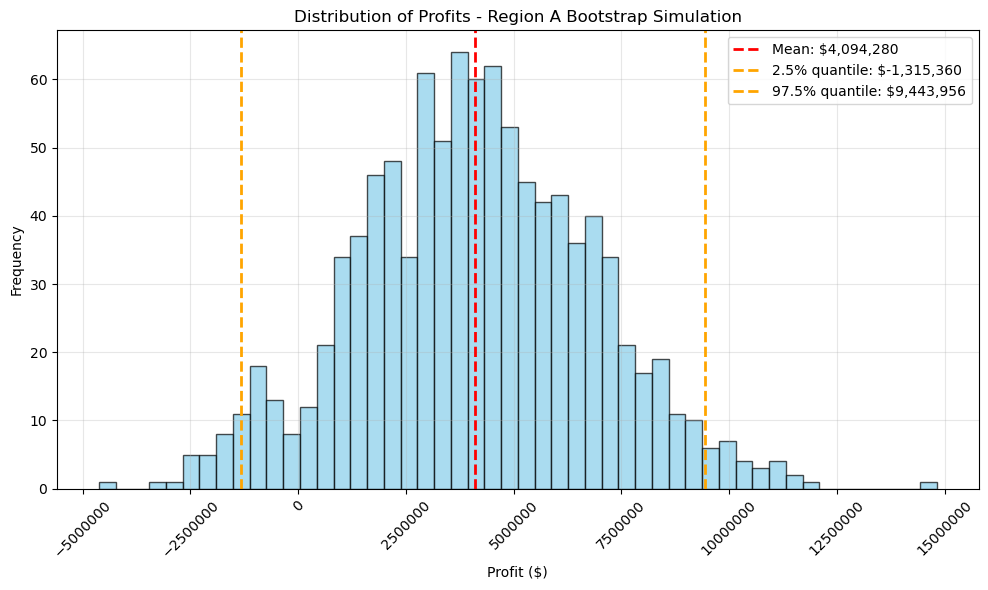

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# Add vertical lines for key statistics
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean:,.0f}')
plt.axvline(lower, color='orange', linestyle='--', linewidth=2, label=f'2.5% quantile: ${lower:,.0f}')
plt.axvline(higher, color='orange', linestyle='--', linewidth=2, label=f'97.5% quantile: ${higher:,.0f}')

# Add labels and title
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Profits - Region A Bootstrap Simulation')
plt.legend()

# Format x-axis to show dollar amounts
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:






def revenue(target, probabilities, count):
    probs_sorted = probabilities.sort_values(ascending=False)
    selected = target[probs_sorted.index][:count]
    total_reserves = selected.sum()  # Total reserves from 200 wells
    total_revenue = total_reserves * revenue_per_barrel * 1000  # Convert to barrels
    total_cost = count * cost_per_well  # Cost of developing 200 wells
    profit = total_revenue - total_cost  # Total profit in dollars
    return profit
    
region_B_predictions_valid = pd.Series(
    region_B_predictions_valid, 
    index=Region_B_valid_target.index
)
state = np.random.RandomState(12345)
    
values = []
for i in range(1000):
    probs_subsample = region_B_predictions_valid.sample(n=500, replace=True, random_state=state)
    target_subsample = Region_B_valid_target[probs_subsample.index]
    # < write code here>
    revenue_value = revenue(target_subsample, probs_subsample, 200)
    values.append(revenue_value)# < write code here>)

values = pd.Series(values)

lower = values.quantile(0.025)# < write code here>
higher = values.quantile(0.975)
mean = values.mean()
print(f"Average profit: ${mean:,.0f}")
print(f".025% quantile: ${lower:,.0f}")
print(f".975% quantile: ${higher:,.0f}")
risk_of_losses = (values < 0).sum() / len(values) * 100
print(f"Risk of losses: {risk_of_losses:.1f}%")





Average profit: $5,369,026
.025% quantile: $1,145,279
.975% quantile: $9,707,879
Risk of losses: 0.9%


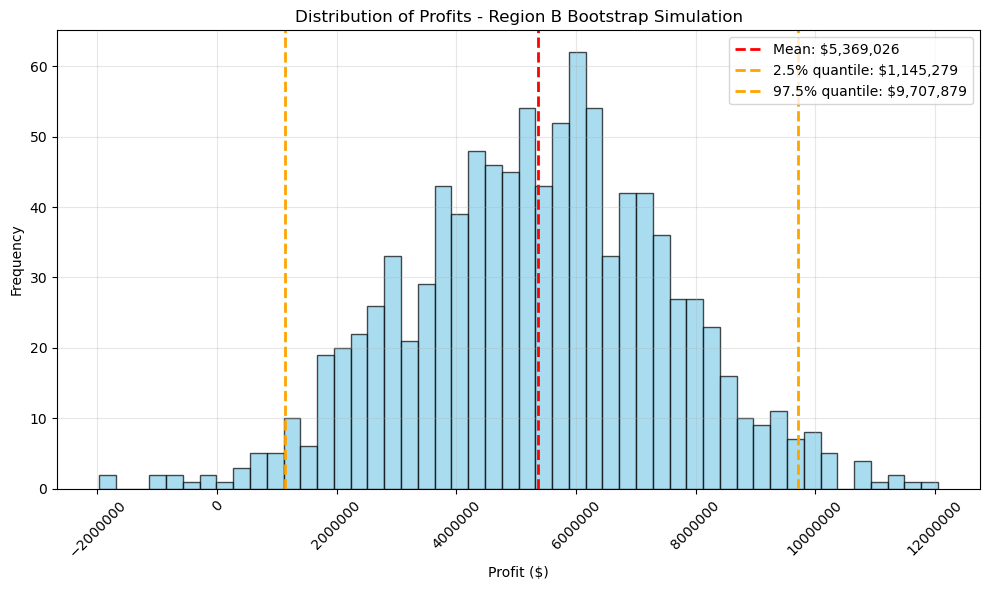

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# Add vertical lines for key statistics
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean:,.0f}')
plt.axvline(lower, color='orange', linestyle='--', linewidth=2, label=f'2.5% quantile: ${lower:,.0f}')
plt.axvline(higher, color='orange', linestyle='--', linewidth=2, label=f'97.5% quantile: ${higher:,.0f}')

# Add labels and title
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Profits - Region B Bootstrap Simulation')
plt.legend()

# Format x-axis to show dollar amounts
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
def revenue(target, probabilities, count):
    probs_sorted = probabilities.sort_values(ascending=False)
    selected = target[probs_sorted.index][:count]
    total_reserves = selected.sum()  # Total reserves from 200 wells
    total_revenue = total_reserves * revenue_per_barrel * 1000  # Convert to barrels
    total_cost = count * cost_per_well  # Cost of developing 200 wells
    profit = total_revenue - total_cost  # Total profit in dollars
    return profit
    
region_C_predictions_valid = pd.Series(
    region_C_predictions_valid, 
    index=Region_C_valid_target.index
)
state = np.random.RandomState(12345)
    
values = []
for i in range(1000):
    probs_subsample = region_C_predictions_valid.sample(n=500, replace=True, random_state=state)
    target_subsample = Region_C_valid_target[probs_subsample.index]
    # < write code here>
    revenue_value = revenue(target_subsample, probs_subsample, 200)
    values.append(revenue_value)# < write code here>)

values = pd.Series(values)

lower = values.quantile(0.025)# < write code here>
higher = values.quantile(0.975)
mean = values.mean()
print(f"Average profit: ${mean:,.0f}")
print(f".025% quantile: ${lower:,.0f}")
print(f".975% quantile: ${higher:,.0f}")
risk_of_losses = (values < 0).sum() / len(values) * 100
print(f"Risk of losses: {risk_of_losses:.1f}%")


Average profit: $3,537,904
.025% quantile: $-1,591,940
.975% quantile: $8,756,525
Risk of losses: 10.2%


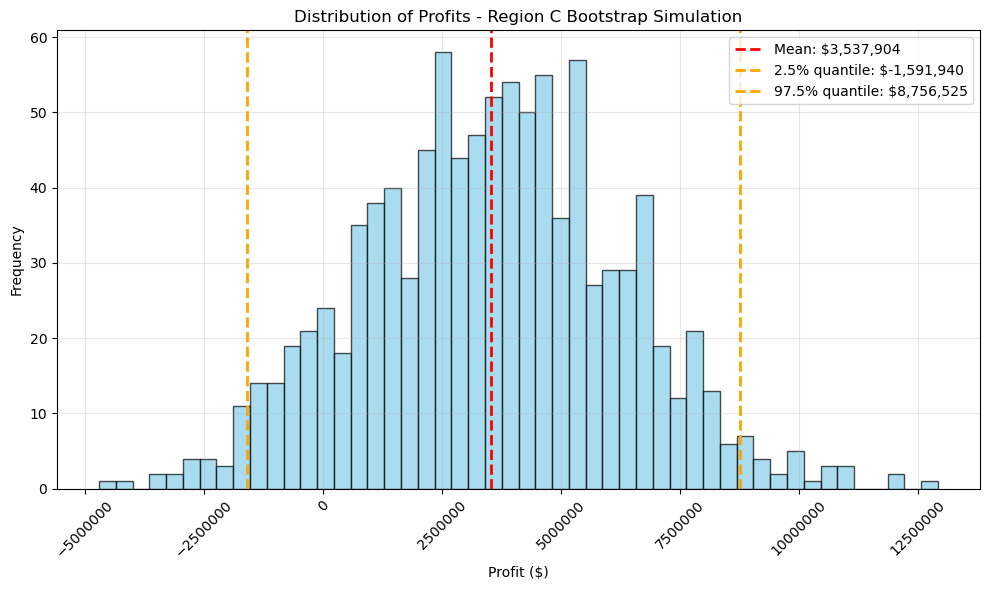

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# Add vertical lines for key statistics
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean:,.0f}')
plt.axvline(lower, color='orange', linestyle='--', linewidth=2, label=f'2.5% quantile: ${lower:,.0f}')
plt.axvline(higher, color='orange', linestyle='--', linewidth=2, label=f'97.5% quantile: ${higher:,.0f}')

# Add labels and title
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Profits - Region C Bootstrap Simulation')
plt.legend()

# Format x-axis to show dollar amounts
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Based on the bootstrap simulation with 1,000 iterations, where 500 wells were sampled and the top 200 were selected each time, Region B demonstrates the most reliable profit performance. The mean profit is $\$5{,}369{,}026$, with a 95% confidence interval ranging from $\$1{,}145{,}279$ to $\$9{,}707{,}879$. The probability of losses is only 0.9%, which is well below the acceptable risk level. This confidence interval reflects the range of expected profit outcomes under repeated sampling and provides a clear estimate of uncertainty and downside risk.

By contrast, Regions A and C show loss probabilities that exceed the acceptable threshold. In these regions, a large number of bootstrap simulations result in negative profit even after selecting the top 200 wells. Because the objective is to maximize profit while maintaining controlled risk, Regions A and C are not suitable from a business standpoint. Region B is therefore the preferred option, as it combines the lowest loss risk with a narrower and more reliable 95% confidence interval, indicating more stable profit outcomes when wells are selected based on model predictions.